# Muon Site & Internal Field Analysis: UCoGe
**Project Framework:** Quantitative validation of local fields in the itinerant superconducting ferromagnet $\text{UCoGe}$.

---

### Experimental Reference Paper
* **Title:** *Muon Spin Rotation and Relaxation in the Superconducting Ferromagnet UCoGe*
* **Citation:** [Phys. Rev. Lett. **102**, 167003 (2009)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.102.167003)
* **Authors:** A. de Visser, N.T. Huy, A. Gasparini, D.E. de Nijs, D. Andreica, C. Baines, and A. Amato
* **Findings:** Zero-field $\mu\text{SR}$ confirms microscopic coexistence of ferromagnetism and superconductivity, measuring a local magnetic field **$B_{\text{loc}} = 0.015\text{ T}$** below $T_{\text{sc}} = 0.5\text{ K}$.

---

### TODO
Find muon-stopping site(s) and internal magnetic field contribution as well as the $\mu\text{SR}$ depolarization signal and 
validates/reproduce the experimental findings:

$$\mathbf{B}_{\text{loc}} = \mathbf{B}_{\text{dipolar}} + \mathbf{B}_{\text{Lorentz}} + \mathbf{B}_{\text{contact}}$$


---

In [1]:
import json
import pickle
import numpy as np
from copy import deepcopy
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.io_tools.qe_query import relax as qe_rlx

from muonscripts.io_tools.dataframe import get_dataframe
from muonscripts.muon_tools.muonic_dataframe import get_dataframe

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muon_tools.aiida_muon.distortions import get_distortions
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data
from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary

from muonscripts.undi_tools.second_moments_avg import second_moments_fn
from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.celio_signal import get_signal
from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.pcefg.point_charge import compute_efg
from muonscripts.pcefg.point_charge import sphere_radius_convergence
from muonscripts.pcefg.point_charge import build_point_charge_efg_neighbors

from muonscripts.symmetry import wyckoff as wyckoff
from muonscripts.symmetry.sites import get_equivalent_sites, get_atom_kinds

from muonscripts.muesr_tools.local_fields import pfields, rfields
from muonscripts.muesr_tools.utils import _extract_muon, get_atom_kinds

from muonscripts.plot_tools.muon import field_bar, fancy_style_axes

In [3]:
def load_raw_data_only(filename, x_min=0):
    """Reads the first 2-3 columns (xData, Data, [errData]) of a muSR
    data file, ignoring any other (e.g. theory) columns."""
    import pandas as pd
    
    df = pd.read_csv(filename, skipinitialspace=True)
    df = df.replace(r"^\s*$", np.nan, regex=True)
    cols = list(df.columns[:3])
    d = df[cols].dropna()
    xData = d[cols[0]].to_numpy(dtype=float)
    yData = d[cols[1]].to_numpy(dtype=float)
    errData = d[cols[2]].to_numpy(dtype=float) if len(cols) > 2 else None
    if x_min is not None:
        keep = xData >= x_min
        xData, yData = xData[keep], yData[keep]
        if errData is not None:
            errData = errData[keep]
    return xData, yData, errData


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [4]:
def kubo_toyabe(tlist, Gmu_S2):
    """Calculates the Kubo-Toyabe polarization for the nuclear arrangement
        provided in input.

    Parameters
    ----------
    tlist : numpy.array
        List of times at which the muon polarization is observed.
    Gmu_S2 : float
        The product of gamma_mu and sigma^2.

    Returns
    -------
    numpy.array
        Kubo-Toyabe function, for a powder in zero field.
    """
    return 0.333333333333 + 0.6666666666 * \
            (1- Gmu_S2  *  np.power(tlist,2)) * \
            np.exp( - 0.5 * Gmu_S2 * np.power(tlist,2))

In [5]:
def compare_neighbors_positions(original, scaled):
    """
    Compare nuclear positions before and after scaling.
    """

    for old, new in zip(original, scaled):

        label = old["Label"]

        if label == "mu":
            continue

        r_old = np.linalg.norm(old["Position"])
        r_new = np.linalg.norm(new["Position"])
        rel_dif = np.linalg.norm(new["Position"]-old["Position"])

        ang = 1e-10
        print(
            f"{label:>5s}  "
            f"|R_old| = {r_old/ang:.6f} Å   "
            f"|R_new| = {r_new/ang:.6f} Å   "
            # f"|R_new|-|R_old| = {(r_new-r_old)/ang: .6f} Å   "
            f"|R_new-R_old| = {rel_dif/ang:.6f} Å   "
            f"|R_new|/|R_old| = {r_new/r_old:.4f}"
        )

In [6]:
import os
dpath='./'

In [7]:
sc_matrix = [
    [2, 0, 0], 
    [0, 2, 0], 
    [0, 0, 3]
    ]

filename = 'UCoGe_pnma.cif'
filename = os.path.join(dpath, filename)
p_st = Structure.from_file(filename)

print(p_st)

Full Formula (U4 Co4 Ge4)
Reduced Formula: UCoGe
abc   :   6.845000   4.206000   7.222000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (12)
  #  SP         a     b       c
---  ----  ------  ----  ------
  0  U     0.0101  0.25  0.7075
  1  U     0.5101  0.25  0.7925
  2  U     0.9899  0.75  0.2925
  3  U     0.4899  0.75  0.2075
  4  Co    0.2887  0.25  0.4172
  5  Co    0.7887  0.25  0.0828
  6  Co    0.7113  0.75  0.5828
  7  Co    0.2113  0.75  0.9172
  8  Ge    0.1967  0.25  0.087
  9  Ge    0.6967  0.25  0.413
 10  Ge    0.8033  0.75  0.913
 11  Ge    0.3033  0.75  0.587


/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/io/cif.py:1314: UserWarning: Missing elements Mn, P from PMG structure composition
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):


In [8]:
# Identify atom kinds

atm_kinds = get_atom_kinds(p_st)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


print("\nU indices:")
print(atm_kinds["U"])


Atom kinds:
U: [0, 1, 2, 3]
Co: [4, 5, 6, 7]
Ge: [8, 9, 10, 11]

U indices:
[0, 1, 2, 3]


In [9]:
print("\nU fractional coordinates:")

for i in atm_kinds["U"]:
    print(
        f"index = {i:3d}   "
        f"frac = {p_st.frac_coords[i]}"
    )


U fractional coordinates:
index =   0   frac = [0.0101 0.25   0.7075]
index =   1   frac = [0.5101 0.25   0.7925]
index =   2   frac = [0.9899 0.75   0.2925]
index =   3   frac = [0.4899 0.75   0.2075]


In [10]:
# Magnetic moment directions
#

U_dir_001  = np.array([0.0, 0.0, 0.07])  # muB
Co_dir_001 = np.array([0.0, 0.0, 0.07])  # muB

print("\nMoment magnitudes:")
print("|U_dir_001| =", np.linalg.norm(U_dir_001))

# Construct magnetic structures

magmoms  = np.zeros((len(p_st), 3))

# FM [001]
magmoms[atm_kinds["U"]] = U_dir_001

magmoms


Moment magnitudes:
|U_dir_001| = 0.07


array([[0.  , 0.  , 0.07],
       [0.  , 0.  , 0.07],
       [0.  , 0.  , 0.07],
       [0.  , 0.  , 0.07],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ]])

The muon site predicted from A. de Visser et. al. PRL 102, 167003 (2009) at 4a Wyckoff position i.e [0, 0, 0]

In [11]:
adv_muon_site = [0, 0, 0]
adv_assumed_or_estimate_contact = -0.005
include_equiv = True
fields_p = pfields(
    structure=p_st.copy(),
    magmoms=magmoms,
    muon_pos=adv_muon_site,
    cont_field=adv_assumed_or_estimate_contact,
    include_equivalent_sites=include_equiv,
    muon_label="H",
)

# Field data extracted from pfields calculation
total_fields = fields_p.total
dipolar_fields = fields_p.dipolar
lorentz_fields = fields_p.lorentz
contact_fields = fields_p.contact
muon_positions = fields_p.muon_positions

# fields_p.total_norm, fields_p.dipolar_norm, fields_p.lorentz_norm, fields_p.muon_positions
# fields_p.total, fields_p.dipolar, fields_p.lorentz, fields_p.muon_positions

In [12]:
# Compute vector magnitudes (norms) across spatial dimensions
total_norms = np.linalg.norm(total_fields, axis=1)
dipolar_norms = np.linalg.norm(dipolar_fields, axis=1)
lorentz_norms = np.linalg.norm(lorentz_fields, axis=1)
contact_norms = np.linalg.norm(contact_fields, axis=1)

print("=" * 90)
print(f"{'Site (frac coords)':<22} | {'Field Type':<10} | {'Vector [Bx, By, Bz] (Tesla)':<32}  | {'|B| (Tesla)':<8}")
print("=" * 90)

for i, pos in enumerate(muon_positions):
    pos_str = f"[{pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f}]"
    
    # Dipolar Contribution
    d_vec = f"[{dipolar_fields[i][0]:+9.6f}, {dipolar_fields[i][1]:+9.6f}, {dipolar_fields[i][2]:+9.6f}]"
    print(f"{pos_str:<22} | {'Dip.':<10} | {d_vec} | {dipolar_norms[i]:8.6f}")
    
    # Lorentz Contribution
    l_vec = f"[{lorentz_fields[i][0]:+9.6f}, {lorentz_fields[i][1]:+9.6f}, {lorentz_fields[i][2]:+9.6f}]"
    print(f"{'':<22} | {'Lor.':<10} | {l_vec} | {lorentz_norms[i]:8.6f}")

    # Contact Contribution
    c_vec = f"[{contact_fields[i][0]:+9.6f}, {contact_fields[i][1]:+9.6f}, {contact_fields[i][2]:+9.6f}]"
    print(f"{'':<22} | {'Cont.':<10} | {c_vec} | {contact_norms[i]:8.6f}")
    
    # Total Field
    t_vec = f"[{total_fields[i][0]:+9.6f}, {total_fields[i][1]:+9.6f}, {total_fields[i][2]:+9.6f}]"
    print(f"{'':<22} | {'Tot.':<10} | {t_vec} | {total_norms[i]:8.6f}")
    
    print("-" * 90)

Site (frac coords)     | Field Type | Vector [Bx, By, Bz] (Tesla)       | |B| (Tesla)
[0.00, 0.00, 0.00]     | Dip.       | [-0.000490, -0.009488, +0.011322] | 0.014780
                       | Lor.       | [+0.000000, +0.000000, +0.005232] | 0.005232
                       | Cont.      | [-0.000000, -0.000000, -0.005000] | 0.005000
                       | Tot.       | [-0.000490, -0.009488, +0.011554] | 0.014959
------------------------------------------------------------------------------------------
[0.50, 0.00, 0.50]     | Dip.       | [+0.000490, +0.009488, +0.011322] | 0.014780
                       | Lor.       | [+0.000000, +0.000000, +0.005232] | 0.005232
                       | Cont.      | [-0.000000, -0.000000, -0.005000] | 0.005000
                       | Tot.       | [+0.000490, +0.009488, +0.011554] | 0.014959
------------------------------------------------------------------------------------------
[0.50, 0.50, 0.50]     | Dip.       | [+0.000490, -0.009488, +0.0113

with DFT+mu relaxations

In [13]:
preview = True

pattern="*.out"
check_input = True
calc_types = "relax"

folder = os.path.join(dpath, 'query/mu0_new')

if preview:
    groups = qe_rlx.get_relax_after_run(
        folder, 
        pattern=pattern, 
        check_input=check_input,
        calc_types=calc_types, 
        verbose=False,
    )
    print(f"\nPreview: {len(groups)} system group(s) found "
            f"(selection filters ignored in preview mode)\n")
    qe_rlx.print_summary(groups)


results = qe_rlx.query(
    path=folder,
    pattern=pattern,
    check_input=check_input,
    calc_types=calc_types,
    group_by_system=True,
    pymatgen=True,
    verbose=True,
    # **select_kwargs
)

file = 'UCoGe_muonchargepositive.pkl'
file = os.path.join(dpath, file)
qe_rlx.save_results(results, file, fmt='pickle')


Preview: 1 system group(s) found (selection filters ignored in preview mode)

  Co-Ge-H-U  nat = 145  ntyp = 4  -> 10 converged runs
  ---------------------------------------
  1 distinct system(s), 10 converged run(s) total
Saved 10 result(s) to UCoGe_muonchargepositive.pkl (pickle)


In [14]:
input_st = p_st.copy()
init_supc = input_st.copy()
init_supc.make_supercell(sc_matrix)

cluster = get_clustering_after_run_from_data(
    results, 
    input_st, 
    sc_matrix, 
    magmom=None
)

print('The cluster keys are:', list(cluster.keys()))

mapping = cluster["mapping"]
unique_cluster = cluster["unique_pos"]

unique_cluster

unique_sorted = {v: i+1 for i, v in enumerate(sorted(set(mapping)))}
remapped = [unique_sorted[x] for x in mapping]

remapped, remapped

print_clustering_summary(
    cluster, 
    # input_st=input_st,   # or None, if you want the supercell positions (NOT GREAT ALL)
    # use_unitcell=True,   # or None, if you want the supercell positions (NOT GREAT ALL)
    # precision=5
)

The cluster keys are: ['unique_pos', 'mag_inequivalent', 'mapping']

UNIQUE MUON SITES (supercell frac. coordinates)
  #        idx        frac_x        frac_y        frac_z       dE (eV)
----------------------------------------------------------------------
  0          4       0.21728      -0.08242      -0.04121       0.00000
  1          3       0.03185       0.08209       0.20841       0.00106
  2          1      -0.02617       0.08165       0.08372       0.33980
  3          5       0.12339      -0.02631       0.15717       0.71453
  4         10       0.12641       0.13898       0.40572       0.71531
  5          9       0.12329       0.19266       0.15806       0.71691
----------------------------------------------------------------------
Total unique sites: 6

MAGNETICALLY INEQUIVALENT SITES PENDING CALCULATION (0) (supercell frac. coordinates)
  (none -- all magnetically inequivalent sites already covered)


In [15]:
unique_cluster[0].keys()

dict_keys(['idx', 'rlxd_struct', 'energy'])

In [16]:
df, df_all = get_dataframe(unique_cluster, sc_matrix)
print(df_all)

  structure_id label     tot_energy         muon_position_sc  \
1            4     A -418972.317741  [0.217, -0.082, -0.041]   
2            3     B -418972.316681    [0.032, 0.082, 0.208]   
3            1     C -418971.977937   [-0.026, 0.082, 0.084]   
4            5     D -418971.603213   [0.123, -0.026, 0.157]   
5           10     E -418971.602433    [0.126, 0.139, 0.406]   
6            9     F -418971.600833    [0.123, 0.193, 0.158]   

        muon_position_uc delta_E  
1  [0.434, 0.836, 0.877]       0  
2  [0.064, 0.164, 0.624]       1  
3  [0.948, 0.164, 0.252]     339  
4  [0.246, 0.948, 0.471]     714  
5  [0.252, 0.278, 0.218]     715  
6  [0.246, 0.386, 0.474]     716  


In [17]:
print(df)

  structure_id label          muon_position delta_E_meV
1            4     A  [0.434, 0.836, 0.877]           0
2            3     B  [0.064, 0.164, 0.624]           1
3            1     C  [0.948, 0.164, 0.252]         339
4            5     D  [0.246, 0.948, 0.471]         714
5           10     E  [0.252, 0.278, 0.218]         715
6            9     F  [0.246, 0.386, 0.474]         716


In [18]:
file = 'UCoGe_clusteredmuonrelax_results.pkl'
file = os.path.join(dpath, file)
qe_rlx.save_results(unique_cluster, file, fmt='pickle')

Saved 6 result(s) to UCoGe_clusteredmuonrelax_results.pkl (pickle)


In [19]:
file = 'UCoGe_clusteredmuonrelax_results.pkl'
file = os.path.join(dpath, file)

data = qe_rlx.load_results(file, fmt='pickle')

idx = 0
d = data[idx]

rlx_st = Structure.from_dict(d["rlxd_struct"])

In [20]:
print(rlx_st)

Full Formula (U48 Co48 Ge48 H1)
Reduced Formula: U48Co48Ge48H
abc   :  13.690000  12.618005  14.444004
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (145)
  #  SP           a          b          c
---  ----  --------  ---------  ---------
  0  U     0.008929   0.084816   0.351528
  1  U     0.007721   0.08342    0.850435
  2  U     0.009054   0.417188   0.351065
  3  U     0.00952    0.417589   0.851125
  4  U     0.008355   0.747997   0.351534
  5  U     0.007572   0.752085   0.850573
  6  U     0.5095     0.084127   0.352347
  7  U     0.508254   0.082559   0.851897
  8  U     0.507765   0.417232   0.35111
  9  U     0.508813   0.417411   0.850825
 10  U     0.50927    0.749825   0.351945
 11  U     0.508225   0.753009   0.852176
 12  U     0.259151   0.084663   0.399018
 13  U     0.258669   0.083129   0.900054
 14  U     0.258556   0.417197   0.399386
 15  U     0.259404   0.417481   0.898543
 16  U     0.259273   0.74889    0.3991
 17  U  

In [21]:
rlx_st_nomu, mupos_sc = _extract_muon(rlx_st, muon_pos=None, muon_label='H')
mupos_sc

array([ 0.21727591, -0.08242356, -0.04120792])

In [22]:
mupos_uc = np.dot(mupos_sc, sc_matrix)%1  # wrap to unitcell
mupos_uc  # same as above in the dataframe

array([0.43455183, 0.83515289, 0.87637625])

In [23]:
np.dot(mupos_uc, np.linalg.inv(sc_matrix))%1

array([0.21727591, 0.41757644, 0.29212542])

calculate local field contributions for the candidate sites

In [24]:
idx = 0
d = data[idx]

rlx_supc = Structure.from_dict(d["rlxd_struct"])

fields_r = rfields(
    p_st=p_st.copy(),
    magmoms=magmoms,
    sc_mat=sc_matrix,
    r_supst=rlx_supc.copy(),
    cont_field=-0.000,
    muon_label="H",
)

# Field data extracted from rfields calculation
total_fields = fields_r.total
dipolar_fields = fields_r.dipolar
lorentz_fields = fields_r.lorentz
contact_fields = fields_r.contact
muon_positions = fields_r.muon_positions

fields_r.total, fields_r.dipolar, fields_r.lorentz, fields_r.contact, fields_r.muon_positions

# fields_r.total_norm, fields_r.dipolar_norm, fields_r.lorentz_norm, fields_r.muon_positions

(array([[ 5.50630199e-04, -9.41256339e-05,  1.01226012e-02]]),
 array([[ 5.50630199e-04, -9.41256339e-05,  4.89083800e-03]]),
 array([[0.        , 0.        , 0.00523176]]),
 array([[-0., -0., -0.]]),
 array([[ 0.21727591, -0.08242356, -0.04120792]]))

In [25]:
print("=" * 90)
print(f"{'Site (frac coords)':<22} | {'Field Type':<10} | {'Vector [Bx, By, Bz] (Tesla)':<32}  | {'|B| (Tesla)':<8}")
print("=" * 90)


contact_list = np.zeros(len(data))

# Note, we only care for the lowest energy sites to add +0.005
contact_list[0:2] = -adv_assumed_or_estimate_contact  # oppsite sign
contact_list

for idx in range(len(data)):
    d = data[idx]

    rlx_supc = Structure.from_dict(d["rlxd_struct"])

    fields_r = rfields(
        p_st=p_st.copy(),
        magmoms=magmoms,
        sc_mat=sc_matrix,
        r_supst=rlx_supc.copy(),
        cont_field=contact_list[idx],  
        muon_label="H",
    )

    # Field data extracted from rfields calculation
    total_fields = fields_r.total
    dipolar_fields = fields_r.dipolar
    lorentz_fields = fields_r.lorentz
    contact_fields = fields_r.contact
    muon_positions = fields_r.muon_positions

    # Compute vector magnitudes (norms) across spatial dimensions
    total_norms = np.linalg.norm(total_fields, axis=1)
    dipolar_norms = np.linalg.norm(dipolar_fields, axis=1)
    lorentz_norms = np.linalg.norm(lorentz_fields, axis=1)
    contact_norms = np.linalg.norm(contact_fields, axis=1)

    # print("=" * 90)
    # print(f"{'Site (frac coords)':<22} | {'Field Type':<10} | {'Vector [Bx, By, Bz] (Tesla)':<32}  | {'|B| (Tesla)':<8}")
    # print("=" * 90)

    for i, pos in enumerate(muon_positions):
        pos_str = f"[{pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f}]"
        
        # Dipolar Contribution
        d_vec = f"[{dipolar_fields[i][0]:+9.6f}, {dipolar_fields[i][1]:+9.6f}, {dipolar_fields[i][2]:+9.6f}]"
        print(f"{pos_str:<22} | {'Dip.':<10} | {d_vec} | {dipolar_norms[i]:8.6f}")
        
        # Lorentz Contribution
        l_vec = f"[{lorentz_fields[i][0]:+9.6f}, {lorentz_fields[i][1]:+9.6f}, {lorentz_fields[i][2]:+9.6f}]"
        print(f"{'':<22} | {'Lor.':<10} | {l_vec} | {lorentz_norms[i]:8.6f}")

        # Contact Contribution
        c_vec = f"[{contact_fields[i][0]:+9.6f}, {contact_fields[i][1]:+9.6f}, {contact_fields[i][2]:+9.6f}]"
        print(f"{'':<22} | {'Cont.':<10} | {c_vec} | {contact_norms[i]:8.6f}")
        
        # Total Field
        t_vec = f"[{total_fields[i][0]:+9.6f}, {total_fields[i][1]:+9.6f}, {total_fields[i][2]:+9.6f}]"
        print(f"{'':<22} | {'Tot.':<10} | {t_vec} | {total_norms[i]:8.6f}")
        
        print("-" * 90)


Site (frac coords)     | Field Type | Vector [Bx, By, Bz] (Tesla)       | |B| (Tesla)
[0.22, -0.08, -0.04]   | Dip.       | [+0.000551, -0.000094, +0.004891] | 0.004923
                       | Lor.       | [+0.000000, +0.000000, +0.005232] | 0.005232
                       | Cont.      | [+0.000000, +0.000000, +0.005000] | 0.005000
                       | Tot.       | [+0.000551, -0.000094, +0.015123] | 0.015133
------------------------------------------------------------------------------------------
[0.03, 0.08, 0.21]     | Dip.       | [-0.000430, +0.000011, +0.004559] | 0.004580
                       | Lor.       | [+0.000000, +0.000000, +0.005231] | 0.005231
                       | Cont.      | [+0.000000, +0.000000, +0.005000] | 0.005000
                       | Tot.       | [-0.000430, +0.000011, +0.014791] | 0.014797
------------------------------------------------------------------------------------------
[-0.03, 0.08, 0.08]    | Dip.       | [+0.002167, -0.000061, -0.0042

### Local Magnetic Field Comparison & Validation

By evaluating the experimental local field baseline of **0.015 T**, two distinct computational treatment for the contact field contribution yield convergent results:

1. **Pristine Calculation:** Incorporating a negative contact field of **$-0.005\text{ T}$** (matching the unrelaxed methodology detailed in the literature) results in a total calculated local field of **$\sim 0.0149\text{ T}$**.
2. **Relaxed DFT+$\mu$:** Incorporating a positive contact field of **$+0.005\text{ T}$** (arising from full DFT+$\mu$ structural relaxations for low energy site) yields a total calculated local field of **$\sim 0.0151\text{ T}$** at Site A.

#### Key Takeaway
Both computational configurations effectively capture the physical reality of the system, converging remarkably close to the experimental **0.015 T** baseline. This indicates that while structural relaxation shifts the sign of the local contact contribution, the resulting total field magnitude remains robustly bounded and consistent with experimental observation.


### Future Outlook: Advanced DFT+$\mu$ Framework for UCoGe

Given that **UCoGe** is a highly correlated heavy-fermion superconductor with a small itinerant ordered moment, future calculations aiming to refine the calculations and estimate contact field should focus on the following:

* **Strong Correlation & Relativistic Effects:** **$\text{DFT}+U+\text{SOC}$** framework is required. Uranium $5f$ electrons demand Hubbard-$U$ corrections, while massive spin-orbit coupling must be active to properly map the interstitial magnetization density.
* **Core-Valence Pseudopotential Precision:** Utilizing PAW datasets that explicitly include semi-core states (e.g., $6s/6p$ for U) ensures that core-polarization tails reaching the interstitial space are not artificially truncated.


plot radial displacements

The maximum displacement is = 0.4569 Å


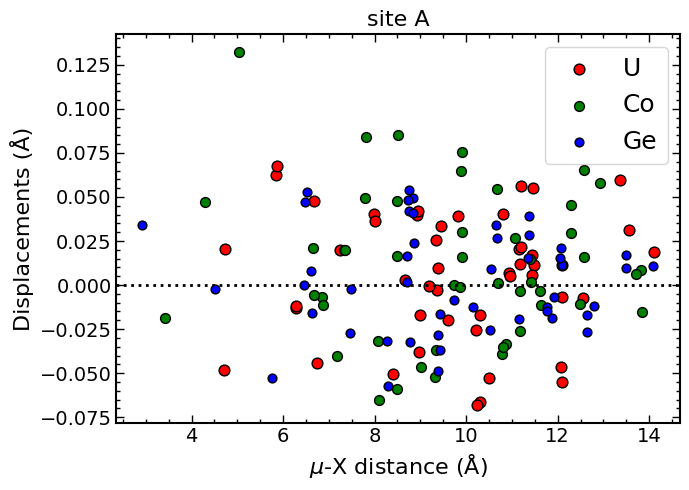

In [26]:
idx=4

pre = f"{idx}"
filename = f"{pre}.in"
filepath = os.path.join(folder, filename)
inp_ase = read_from_file(filepath, format="espresso-in")

filename = f"{pre}.out"
filepath = os.path.join(folder, filename)
rlx_ase = read_from_file(filepath, format="espresso-out", index=-1)

# let us workaround and test input
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]
mupos_rlx

p_stsc = p_st.copy()
p_stsc.make_supercell(sc_matrix)
p_stsc.append(
    species="H",
    coords=mupos_rlx,
    coords_are_cartesian=False,
    validate_proximity=True,
    properties={"kind_name": "H"},
)
inp_ase = AseAtomsAdaptor.get_atoms(p_stsc)


radial_res = radial_to_dict(inp_ase.copy(), rlx_ase.copy(), muon_label='H')


fontsize=16
fig, ax = plt.subplots(figsize=(7, 5))

max_disp = max_displacement(inp_ase.copy(), rlx_ase.copy())

print(f'The maximum displacement is = {max_disp:.4f} Å')


specie_dict = {
    'U': {
        'color': 'red',
        'size': 60
    },
    'Co': {
        'color': 'green',
        'size': 50
    },
    'Ge': {
        'color': 'blue',
        'size': 40
    },
}

for i, specie in enumerate(specie_dict.keys()):
    sel = select_radial_displacement(
        radial_res,
        species=specie,
        distance_type='unperturbed',
        # cutoff=6.0,          # None -> no cutoff, keep everything
    )
    ax.scatter(
        sel['distance'], sel['displacements'], 
        color=specie_dict[specie]['color'], s=specie_dict[specie]['size'], 
        edgecolor='k', label=specie, zorder=i+1
        )

ax.set_title(r'site A', fontsize=fontsize)
ax.set_xlabel(r'$\mu$-X distance (Å)', fontsize=fontsize)
ax.set_ylabel(r'Displacements (Å)' , fontsize=fontsize)

# ax.set_xlim([+1.00, 12.0])
# ax.set_ylim([-0.15, 0.25])
ax.axhline(y=0.0, ls='dotted', lw=2, color='k')

ax.legend(frameon=False)
ax.legend(
    loc="best", fontsize=fontsize+2, ncol=1,
    frameon=True, handlelength=1.9, columnspacing=1.2,
)
fancy_style_axes(ax, fontsize=fontsize-2)


plt.tight_layout()
figname='UCoGe_siteA_displacements.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

compute seconds moments and depolarization signal for lowest energy site A

In [27]:
file = '4.in'
file = os.path.join(folder, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [28]:
file = '4.out'
file = os.path.join(folder, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [29]:
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]

mupos_rlx

array([0.21727591, 0.91757644, 0.95879208])

In [30]:
cutoffs_deep = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
sm_contribs = second_moments_fn(
    atoms=rlx_ase2.copy(), 
    muon_position=mupos_rlx, 
    cutoff=cutoffs_deep
)
Gmu_S2 = sum(sm_contribs.values())

print('Contributions to the total second moment (sigma^2) from each nuclear species:')
width = max((len(s) for s in sm_contribs), default=5)
width = max(width, len('Total'))

# Loop over species and print absolute + percentage contributions
for symbol, val in sm_contribs.items():
    pct = (val / Gmu_S2) * 100 if Gmu_S2 > 0 else 0.0
    print(f"  {symbol:>{width}s}: {val:20.6f} (rad^2/s^2) | {pct:7.3f}%")
print(f"  {'Total':>{width}s}: {Gmu_S2:20.6f} (rad^2/s^2) | 100.000%")
print(f"")

Contributions to the total second moment (sigma^2) from each nuclear species:
     Co:  136217990519.502808 (rad^2/s^2) |  99.922%
     Ge:     102576918.108066 (rad^2/s^2) |   0.075%
      U:       3644322.330936 (rad^2/s^2) |   0.003%
  Total:  136324211759.941803 (rad^2/s^2) | 100.000%



In [31]:
print(f"The Delta value is = {np.sqrt(Gmu_S2)*1e-6:.4f} us^-1")
print(f" close to the experimental value of 0.30+/-0.01 us^-1")
pct_err = ((np.sqrt(Gmu_S2)*1e-6-0.30)/0.30)*100
print(f" overestimated by {pct_err:.1f} %")

The Delta value is = 0.3692 us^-1
 close to the experimental value of 0.30+/-0.01 us^-1
 overestimated by 23.1 %


prepare atoms 'neighbors' for undi (depolarizations) calculations

In [32]:
inf_cutoff=10
cutoffs = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
cutoffs = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
cutoffs = {'Co': 3.50,}
print("== Building neighbor cluster ==")
neighbors = build_undi_neighbors(
    rlx_ase2,
    mupos_rlx,
    cutoffs=cutoffs,
    inf_cutoff=inf_cutoff,
    efg_tensors=None,
    efg_factor=1.0,
    gamma_overrides=None,
    isotope_overrides={'U': '235U', 'Co': '59Co', 'Ge': '73Ge'},
    quadrupole_moments_overrides=None,
    verbose_neighbors=True,
    # format='elk'
    # **read_kwargs,
)

# complete missing nuclear properties
neighbors = complete_undi_neighbors(neighbors, log_level="")

neighbors

neighbors_hilbert_dimension(neighbors)

== Building neighbor cluster ==
Adding atom #60  Co   with position (Å): [  2.3599,   2.1412,   1.1837] and distance: 3.3992 Å
[override] isotope: Co -> 59Co
Adding atom #77  Co   with position (Å): [  1.9947,  -0.0012,  -2.4039] and distance: 3.1237 Å
[override] isotope: Co -> 59Co
Adding atom #89  Co   with position (Å): [ -1.7254,  -0.0038,  -0.0656] and distance: 1.7266 Å
[override] isotope: Co -> 59Co
Adding atom #64  Co   with position (Å): [  2.3666,  -2.1281,   1.1723] and distance: 3.3918 Å
[override] isotope: Co -> 59Co


8192

In [33]:
# copy
original_neighbors = deepcopy(neighbors)

include point-charge EFG

In [34]:
# CONFIGURATION SWITCHES
USE_FORMAL_CHARGES = True    # True: Set A (+3/-1/-2) | False: Set B (+1.2/-0.6/-0.6)
APPLY_STERNHEIMER  = True     # True: apply (1 - gamma_inf) correction | False: raw lattice EFG
INCLUDE_MUON       = True     # Set True if computing EFG with the muon present


# Define Charge Sets
if USE_FORMAL_CHARGES:
    UCoGe_charges = {
        'U':  +3.0,
        'Co': -1.0,
        'Ge': -2.0,
        # 'H':  +1.0   # Muon site charge (optional)
    }
    print("Running with FORMAL / NOMINAL charges: U=+3, Co=-1, Ge=-2")
else:
    UCoGe_charges = {
        'U':  +1.2,
        'Co': -0.6,
        'Ge': -0.6,
        # 'H':  +1.0   # Muon site charge (optional)
    }
    print("Running with HYBRIDIZED / BADER charges: U=+1.2, Co=-0.6, Ge=-0.6")


# Define Sternheimer Antishielding Factors (gamma_infinity)
# Values derived from atomic HF calculations (Sternheimer factors)
sternheimer_gamma_inf = {
    'Co': -9.00,   # Typical factor for Cobalt ions (~ -9 to -12)
    'Ge': -18.0,   # Germanium factor
    'U':  -80.0,   # Actinide heavy core (very large amplification)
    'H':   0.0     # Proton/Muon has no core electrons (gamma_inf = 0)
}
"""VARIOUS Reference for Sternheimer antishielding factor of Co
Value  | Reference
----------------
-7     | T. P. Das and M. Pomerantz, Phys. Rev. 123,2070 (1961) --> Table I
-8.85  | K. D. Sen and P. T. Narasimhan, Phys. Rev. A 14, 539 (1976) --> Tabel I
-7.63  | R. P. Gupta and S. K. Sen, Phys. Rev. B 12, 15 (1975) --> Tabel I

"""
sphere_radius = 60
include_efg = True

# only interested on 'Co'
gamma_sternheimer = 0
if APPLY_STERNHEIMER:
    gamma_sternheimer = sternheimer_gamma_inf['Co']
gamma_sternheimer

Running with FORMAL / NOMINAL charges: U=+3, Co=-1, Ge=-2


-9.0

In [35]:
neighbors = scale_neighbors(
    original_neighbors.copy(), scale=1+(0/100), mode="multiplicative", include_muon=True
)

quadrupolar_neighbors = build_point_charge_efg_neighbors(
    rlx_ase2,
    neighbors=neighbors.copy(),
    muon_position=mupos_rlx,
    atomic_charges=UCoGe_charges,
    sphere_radius=sphere_radius,
    gamma_sternheimer=gamma_sternheimer,
    include_nuclear_efg=include_efg,
    remove_efg_noise=False,
    efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=True,
    include_muon=True
)

Point-charge EFG: summing 52229 charges within radius 60.000 Å.
Point-charge EFG: summing 52236 charges within radius 60.000 Å.
Point-charge EFG: summing 52195 charges within radius 60.000 Å.
Point-charge EFG: summing 52236 charges within radius 60.000 Å.


In [36]:
quadrupolar_original_neighbors =  deepcopy(quadrupolar_neighbors)

In [37]:
pct_scaling = 1.0
neighbors_scaled = scale_neighbors(
    original_neighbors.copy(), scale=1+(pct_scaling/100.0), mode="multiplicative", include_muon=True
)

quadrupolar_neighbors_scaled = build_point_charge_efg_neighbors(
    rlx_ase2,
    neighbors=neighbors_scaled.copy(),
    muon_position=mupos_rlx,
    atomic_charges=UCoGe_charges,
    sphere_radius=sphere_radius,
    gamma_sternheimer=gamma_sternheimer,
    include_nuclear_efg=include_efg,
    remove_efg_noise=False,
    efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=True,
    include_muon=True
)

Point-charge EFG: summing 52225 charges within radius 60.000 Å.
Point-charge EFG: summing 52235 charges within radius 60.000 Å.
Point-charge EFG: summing 52211 charges within radius 60.000 Å.
Point-charge EFG: summing 52222 charges within radius 60.000 Å.


In [38]:
compare_neighbors_positions(original_neighbors, neighbors_scaled)

 59Co  |R_old| = 3.399248 Å   |R_new| = 3.433240 Å   |R_new-R_old| = 0.033992 Å   |R_new|/|R_old| = 1.0100
 59Co  |R_old| = 3.123723 Å   |R_new| = 3.154960 Å   |R_new-R_old| = 0.031237 Å   |R_new|/|R_old| = 1.0100
 59Co  |R_old| = 1.726630 Å   |R_new| = 1.743897 Å   |R_new-R_old| = 0.017266 Å   |R_new|/|R_old| = 1.0100
 59Co  |R_old| = 3.391757 Å   |R_new| = 3.425674 Å   |R_new-R_old| = 0.033918 Å   |R_new|/|R_old| = 1.0100


In [39]:
# Time values, in seconds
tlist = np.linspace(0, 8e-6, 1000)
# tlist = np.linspace(0.0, 15e-6, 101)
tlist_us = tlist*1e6
k=4
nrep=4

calculate signal with no EFG

In [40]:
signal_noEFG = get_signal(
    neighbors=original_neighbors.copy(),
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="xyz",
)

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


[INFO] Running powder average using scheme: 'xyz'


Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


calculate signal with EFG, with no position scaling

In [41]:
signal_EFG = get_signal(
    neighbors=quadrupolar_neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="xyz",
)

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


[INFO] Running powder average using scheme: 'xyz'


Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


calculate signal with EFG, with position scaling

In [42]:
signal_EFG_scaled = get_signal(
    neighbors=quadrupolar_neighbors_scaled,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="xyz",
)

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


[INFO] Running powder average using scheme: 'xyz'


Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


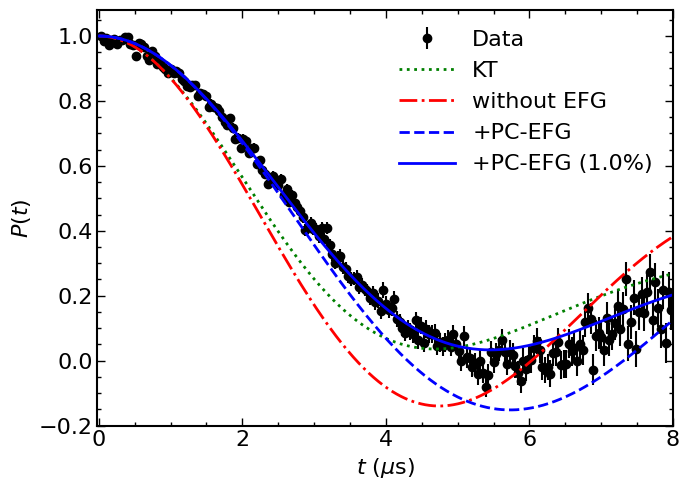

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

file = 'UCoGe_ZFmuSR_6K.dat'
file = os.path.join(dpath, file)
xData, yData, errData = load_raw_data_only(file, x_min=0.0)   # drop the t<0 "prompt" artifact bin
# print(len(yData))
ax.errorbar(xData, yData/yData.max(), yerr=errData/yData.max(), fmt='o', color='black', alpha=1.0, ms=6, label='Data')
ax.errorbar(tlist_us, kubo_toyabe(tlist, Gmu_S2=Gmu_S2), color='green', ls=':', lw=2, label=r'KT')

ax.errorbar(tlist_us, signal_noEFG, color='r', ls='-.', lw=2, label=r'without EFG')
ax.errorbar(tlist_us, signal_EFG, color='b', ls='--', lw=2, label=r'+PC-EFG')
ax.errorbar(tlist_us, signal_EFG_scaled, color='b', ls='-', lw=2, label=f'+PC-EFG ({pct_scaling}%)')

fontsize=16

# ax.set_title(r"UCoGe, $d_{\mathrm{Co}\text{-}{\mu}}$=1.723 Å (perturbed, 4  Co atoms: 1 nn, 1 nnn, 2 nnnn)", fontsize=fontsize-3)
# ax.set_title(r"V$_3$Si, $d_{\mathrm{V}\text{-}{\mu}}$=1.7553 Å (perturbed, 4 nn V)", fontsize=fontsize-3)

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=fontsize)
ax.set_ylabel(r"$P(t)$", fontsize=fontsize)

ax.set_xlim([-0.02, 8.00])
ax.set_ylim([-0.20, 1.08])

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.0,
    labelsize=fontsize,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.0,
)

prop={'size': 16, 'weight':'normal'}
handler_map={
    tuple: matplotlib.legend_handler.HandlerTuple(ndivide=5, pad=1), # ndivide=None
}
_ordered_legend(
    ax, 
    order_list=('Data', ), 
    prop=prop, 
    frameon=False, 
    # handler_map=handler_map,
    handlelength=2.5, columnspacing=1.2,
)
# ax.legend()

plt.tight_layout()
figname='UCoGe_computed_polarization.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

### Key Findings from Muon Site (Site A) Simulation

* **Site A Local Environment:** The local neighborhood is defined by **4 cobalt atoms**, featuring a highly localized closest neighbor at **1.7266 Å**, followed by outer shell neighbors at distances of **3.1237 Å**, **3.3918 Å**, and **3.3992 Å** (see figure below).
* **Inadequacy of Standard KT Model:** The figure above (**'UCoGe_computed_polarization.png'**) show standard Kubo-Toyabe (KT) depolarization function at site A, which reflects the field distribution at the muon site due to the nuclear moments, with the second moment (width) of the field distribution computed in the limit of strong quadrupolar interactions, taking into account isotopes averages and the lattice distortions induced by the muon. However, the figure highlights the critical importance of including Electric Field Gradient (EFG) quadrupolar interaction contributions.
* **Point-Charge EFG Improvements:** While the agreement between experimental data and simulations utilizing the point-charge (PC) EFG model is not perfect, the position of the signal dip is clearly and accurately reproduced, thus validating the predicted site.
* **Structural Relaxation & Agreement:** Incorporating a 1.0% increase in the perturbed muon-X ($\mu\mathrm{-X}$) distances alongside the PC-EFG calculation yields a significantly improved agreement with the experimental data.  
* **Sensititvity:** This markerd improvement against experimental data demonstrates the sensitivity of $\mu\mathrm{SR}$ depolarization signal to atomic distances and EFG
* **Future Outlook:** Better agreement with experiment can be obtained incorporating the full-electron quantum treatment of the muon-nuclear interactions to compute the EFG tensor from first principles (DFT) rather than point-charge approximations.

<div align="center">
    <img src="input_tmpl2/UCoGe_muonsite_AB.png" width="800px" />
</div>

Estimating the changes/scaling imposed to the nuclear positions: site A

In [44]:
cell = rlx_ase2.get_cell()
inverse_cell = np.linalg.inv(cell)

orig_fcoord = []
print(f"The relaxed nuclear positions (frac. coords.) without scaling:")
for atom in original_neighbors:
    if atom.get("Label") == "mu":
        # print()
        continue

    position = atom["Position"]
    fcoord = np.dot(position/constants.ANGSTROM, inverse_cell) + mupos_rlx
    fcoord %=1.0
    orig_fcoord.append(fcoord)
        
    print(f"{atom['Label']} {fcoord} --> magn = {np.linalg.norm(position/constants.ANGSTROM):.6f} Å")

orig_fcoord = np.array(orig_fcoord)

The relaxed nuclear positions (frac. coords.) without scaling:
59Co [0.38965989 0.08726711 0.04073959] --> magn = 3.399248 Å
59Co [0.36298012 0.91748172 0.79236147] --> magn = 3.123723 Å
59Co [0.09124377 0.9172742  0.95425116] --> magn = 1.726630 Å
59Co [0.39014531 0.7489175  0.03995495] --> magn = 3.391757 Å


In [45]:
cell = rlx_ase2.get_cell()
inverse_cell = np.linalg.inv(cell)

scale_fcoord = []
print(f"The relaxed nuclear positions (frac. coords.) with scaling: by {pct_scaling}%")
for atom in quadrupolar_neighbors_scaled:
    if atom.get("Label") == "mu":
        # print()
        continue

    position = atom["Position"]
    fcoord = np.dot(position/constants.ANGSTROM, inverse_cell) + mupos_rlx
    fcoord %=1.0
    scale_fcoord.append(fcoord)
        
    print(f"{atom['Label']} {fcoord} --> magn = {np.linalg.norm(position/constants.ANGSTROM):.6f} Å")

scale_fcoord = np.array(scale_fcoord)

The relaxed nuclear positions (frac. coords.) with scaling: by 1.0%
59Co [0.39138373 0.08896401 0.04155906] --> magn = 3.433240 Å
59Co [0.36443716 0.91748078 0.79069716] --> magn = 3.154960 Å
59Co [0.08998345 0.91727117 0.95420575] --> magn = 1.743897 Å
59Co [0.39187401 0.74723091 0.04076658] --> magn = 3.425674 Å


In [46]:
delta_fcoord = scale_fcoord-orig_fcoord
delta_fcoord
print(f"The changes of the scaling (frac. coords.) imposed by {pct_scaling}%")
for i, delta in enumerate(delta_fcoord):
    print(f"Atom #{i+1:2d} -> [{delta[0]: .6f}, {delta[1]: .6f}, {delta[2]: .6f}]")

The changes of the scaling (frac. coords.) imposed by 1.0%
Atom # 1 -> [ 0.001724,  0.001697,  0.000819]
Atom # 2 -> [ 0.001457, -0.000001, -0.001664]
Atom # 3 -> [-0.001260, -0.000003, -0.000045]
Atom # 4 -> [ 0.001729, -0.001687,  0.000812]


In [47]:
delta_coord = np.dot(delta_fcoord, cell)
delta_magn = np.linalg.norm(delta_coord, axis=1)  # in Angstroms
print("In cartesian coordinates:")
for i, delta in enumerate(delta_coord):
    print(f"Atom #{i+1:2d} -> [{delta[0]: .6f}, {delta[1]: .6f}, {delta[2]: .6f}]  --> magn = {delta_magn[i]:.6f} Å")

In cartesian coordinates:
Atom # 1 -> [ 0.023599,  0.021412,  0.011837]  --> magn = 0.033992 Å
Atom # 2 -> [ 0.019947, -0.000012, -0.024039]  --> magn = 0.031237 Å
Atom # 3 -> [-0.017254, -0.000038, -0.000656]  --> magn = 0.017266 Å
Atom # 4 -> [ 0.023666, -0.021281,  0.011723]  --> magn = 0.033918 Å
